ReLU

学習を開始します...
Epoch 500: Loss 1.898167e-04 | LR 0.005000
Epoch 1000: Loss 5.914316e-05 | LR 0.005000
Epoch 1500: Loss 3.806851e-05 | LR 0.005000
Epoch 2000: Loss 2.867078e-05 | LR 0.005000
Epoch 2500: Loss 4.030218e-05 | LR 0.005000
Epoch 3000: Loss 1.543667e-05 | LR 0.005000
Epoch 3500: Loss 4.031424e-05 | LR 0.005000
Epoch 4000: Loss 1.057761e-05 | LR 0.002500
Epoch 4500: Loss 9.368682e-06 | LR 0.002500
Epoch 5000: Loss 8.385218e-06 | LR 0.002500
訓練が完了しました。
Max Relative Error: 0.016070


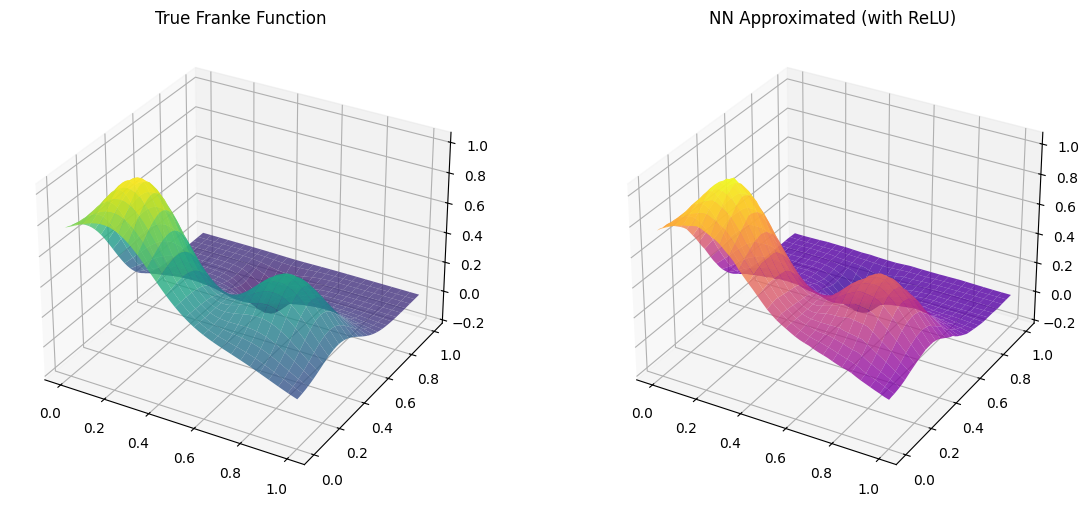

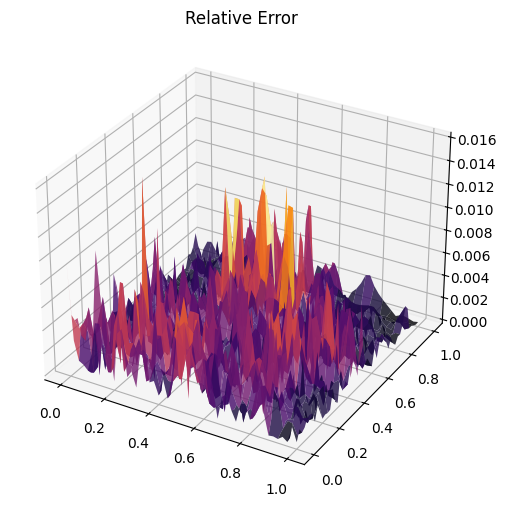

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

# モデル定義: 4層の ReLU
class ReLU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = ReLU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
# 【重要】学習スケジューラの定義
# factor: 学習率を何倍にするか, patience: 何エポック改善しなかったら下げるか
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
    
    # スケジューラに損失を報告して学習率を更新
    scheduler.step(loss)
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Franke Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with ReLU)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

tanh

学習を開始します...
Epoch 500: Loss 5.423160e-04 | LR 0.005000
Epoch 1000: Loss 1.286767e-04 | LR 0.005000
Epoch 1500: Loss 6.269361e-05 | LR 0.005000
Epoch 2000: Loss 4.377296e-05 | LR 0.002500
Epoch 2500: Loss 2.756392e-05 | LR 0.002500
Epoch 3000: Loss 1.738143e-05 | LR 0.002500
Epoch 3500: Loss 1.319089e-05 | LR 0.001250
Epoch 4000: Loss 9.896152e-06 | LR 0.001250
Epoch 4500: Loss 7.384554e-06 | LR 0.001250
Epoch 5000: Loss 5.694754e-06 | LR 0.001250
訓練が完了しました。
Max Relative Error: 0.026605


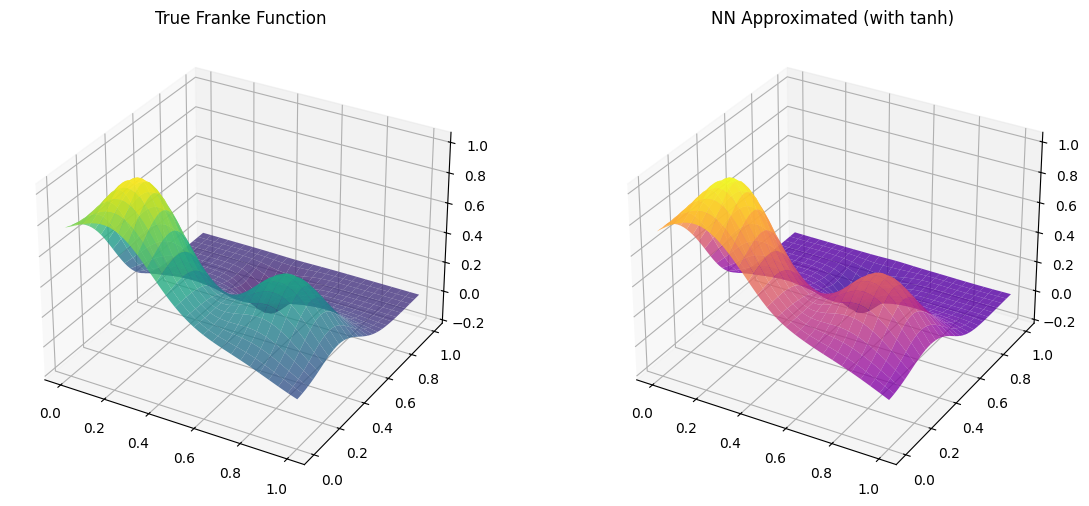

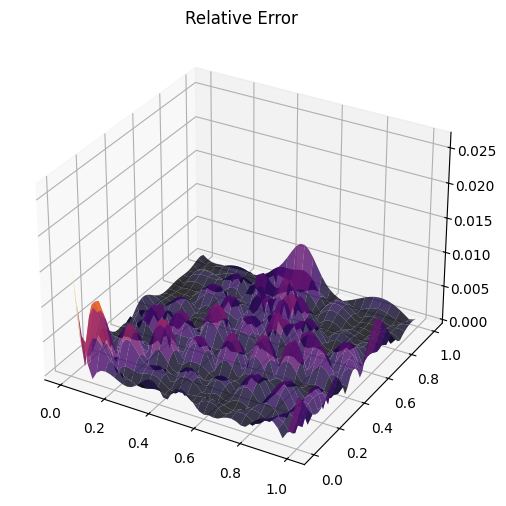

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (tanh を使用)
class Tanh_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = Tanh_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)
# 【重要】学習スケジューラの定義
# factor: 学習率を何倍にするか, patience: 何エポック改善しなかったら下げるか
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
    
    # スケジューラに損失を報告して学習率を更新
    scheduler.step(loss)
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Franke Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with tanh)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

SiLU

学習を開始します...
Epoch 500: Loss 3.979992e-04 | LR 0.005000
Epoch 1000: Loss 8.067625e-05 | LR 0.005000
Epoch 1500: Loss 1.838321e-05 | LR 0.005000
Epoch 2000: Loss 8.292627e-06 | LR 0.005000
Epoch 2500: Loss 5.961826e-05 | LR 0.005000
Epoch 3000: Loss 4.583301e-06 | LR 0.002500
Epoch 3500: Loss 3.556927e-06 | LR 0.002500
Epoch 4000: Loss 2.712504e-06 | LR 0.002500
Epoch 4500: Loss 3.063029e-05 | LR 0.002500
Epoch 5000: Loss 1.842937e-06 | LR 0.002500
訓練が完了しました。
Max Relative Error: 0.006532


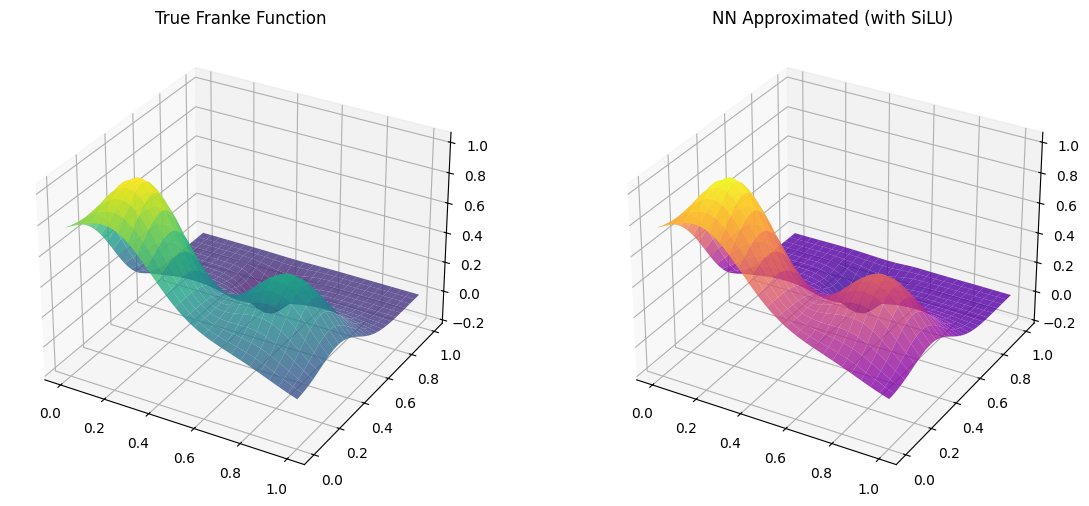

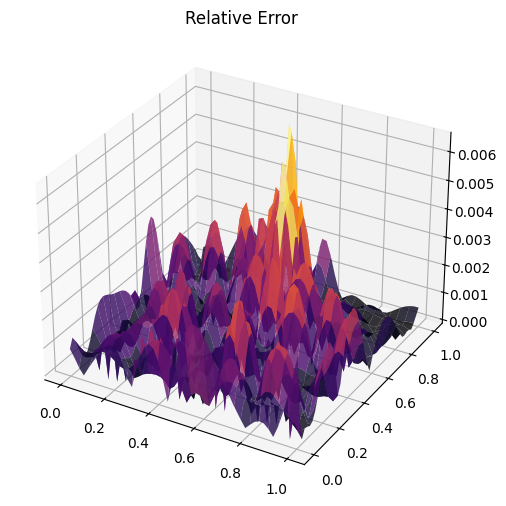

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (SiLU を使用)
class SiLU_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),  # 幅を64に縮小
            nn.SiLU(),         # 活性化関数
            nn.Linear(64, 64), # 中間層1
            nn.SiLU(),
            nn.Linear(64, 64), # 中間層2
            nn.SiLU(),
            nn.Linear(64, 64), # 中間層3
            nn.SiLU(),
            nn.Linear(64, 1)   # 出力層
        )
    def forward(self, x):
        return self.net(x)

model = SiLU_MLP()
optimizer = optim.Adam(model.parameters(), lr=0.005)
# 【重要】学習スケジューラの定義
# factor: 学習率を何倍にするか, patience: 何エポック改善しなかったら下げるか
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
    
    # スケジューラに損失を報告して学習率を更新
    scheduler.step(loss)
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Franke Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with SiLU)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

GELU

学習を開始します...


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\optim\lr_scheduler.py:1691: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  current = float(metrics)


Epoch 500: Loss 1.669324e-04 | LR 0.005000
Epoch 1000: Loss 3.479854e-04 | LR 0.005000
Epoch 1500: Loss 4.666725e-06 | LR 0.005000
Epoch 2000: Loss 2.867386e-06 | LR 0.002500
Epoch 2500: Loss 1.636522e-06 | LR 0.002500
Epoch 3000: Loss 1.025749e-06 | LR 0.002500
Epoch 3500: Loss 2.765427e-05 | LR 0.002500
Epoch 4000: Loss 6.751690e-07 | LR 0.001250
Epoch 4500: Loss 5.764365e-07 | LR 0.001250
Epoch 5000: Loss 1.174507e-06 | LR 0.001250
訓練が完了しました。
Max Relative Error: 0.002632


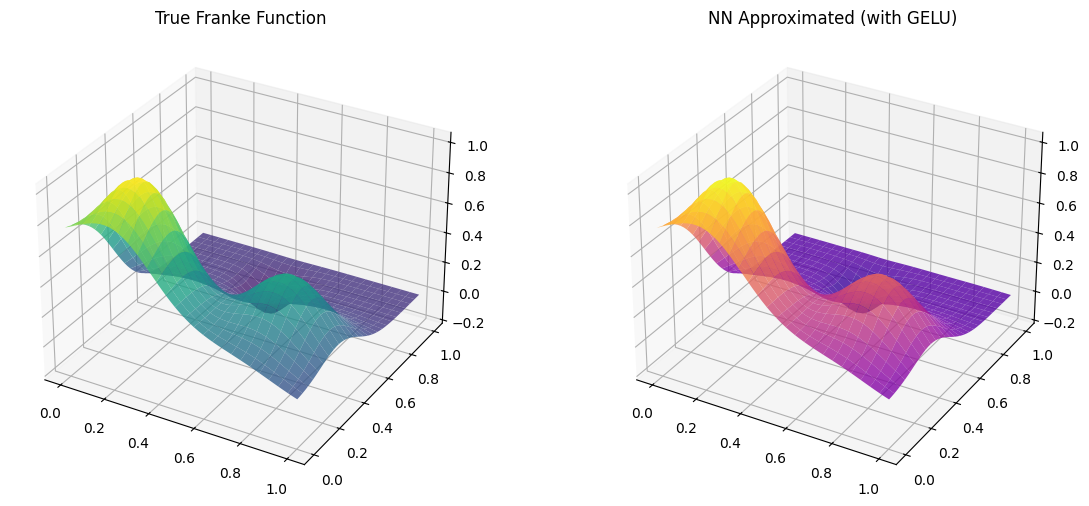

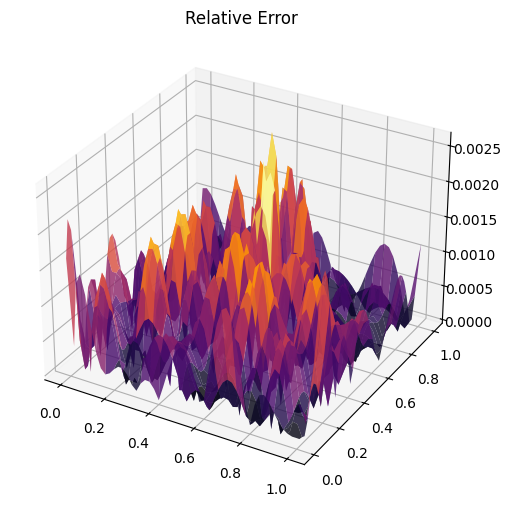

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (GELU を使用)
# モデル定義 (これまでの4層モデル)
class GELU_MLP_4Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = GELU_MLP_4Layer()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# 【重要】学習スケジューラの定義
# factor: 学習率を何倍にするか, patience: 何エポック改善しなかったら下げるか
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
    
    # スケジューラに損失を報告して学習率を更新
    scheduler.step(loss)
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Franke Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with GELU)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

学習を開始します...
Epoch 500: Loss 4.082838e-04 | LR 0.005000
Epoch 1000: Loss 1.747707e-04 | LR 0.005000
Epoch 1500: Loss 8.214244e-05 | LR 0.005000
Epoch 2000: Loss 2.055094e-05 | LR 0.005000
Epoch 2500: Loss 1.023900e-05 | LR 0.002500
Epoch 3000: Loss 5.837171e-06 | LR 0.002500
Epoch 3500: Loss 3.511389e-06 | LR 0.002500
Epoch 4000: Loss 2.461445e-06 | LR 0.002500
Epoch 4500: Loss 1.932721e-06 | LR 0.001250
Epoch 5000: Loss 1.637764e-06 | LR 0.001250
訓練が完了しました。
Max Relative Error: 0.006244


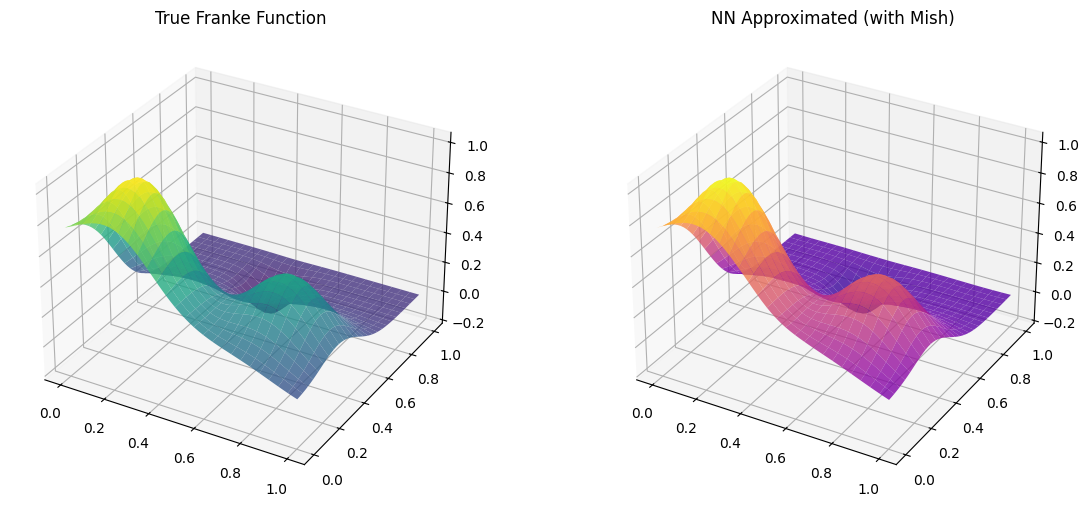

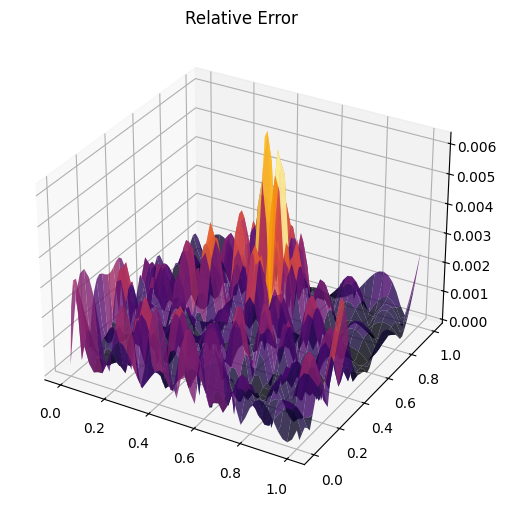

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

# 3. モデル定義 (Mish を使用)
class Mish_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),  # 幅を64に縮小
            nn.Mish(),         # 活性化関数
            nn.Linear(64, 64), # 中間層1
            nn.Mish(),
            nn.Linear(64, 64), # 中間層2
            nn.Mish(),
            nn.Linear(64, 64), # 中間層3
            nn.Mish(),
            nn.Linear(64, 1)   # 出力層
        )
    
    def forward(self, x):
        return self.net(x)

model = Mish_MLP()
optimizer = optim.Adam(model.parameters(), lr=0.005)
# 【重要】学習スケジューラの定義
# factor: 学習率を何倍にするか, patience: 何エポック改善しなかったら下げるか
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
    
    # スケジューラに損失を報告して学習率を更新
    scheduler.step(loss)
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")

# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Franke Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Mish)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()

有理関数活性化関数(2次の簡易版)

学習を開始します...
Epoch 500: Loss 3.077156e-04 | LR 0.005000
Epoch 1000: Loss 1.069075e-04 | LR 0.005000
Epoch 1500: Loss 1.524420e-05 | LR 0.005000
Epoch 2000: Loss 5.188434e-06 | LR 0.005000
Epoch 2500: Loss 2.936029e-06 | LR 0.005000
Epoch 3000: Loss 2.225582e-06 | LR 0.002500
Epoch 3500: Loss 1.734300e-06 | LR 0.002500
Epoch 4000: Loss 1.377727e-06 | LR 0.002500
Epoch 4500: Loss 1.229120e-06 | LR 0.002500
Epoch 5000: Loss 1.035733e-06 | LR 0.001250
訓練が完了しました。
Max Relative Error: 0.005089


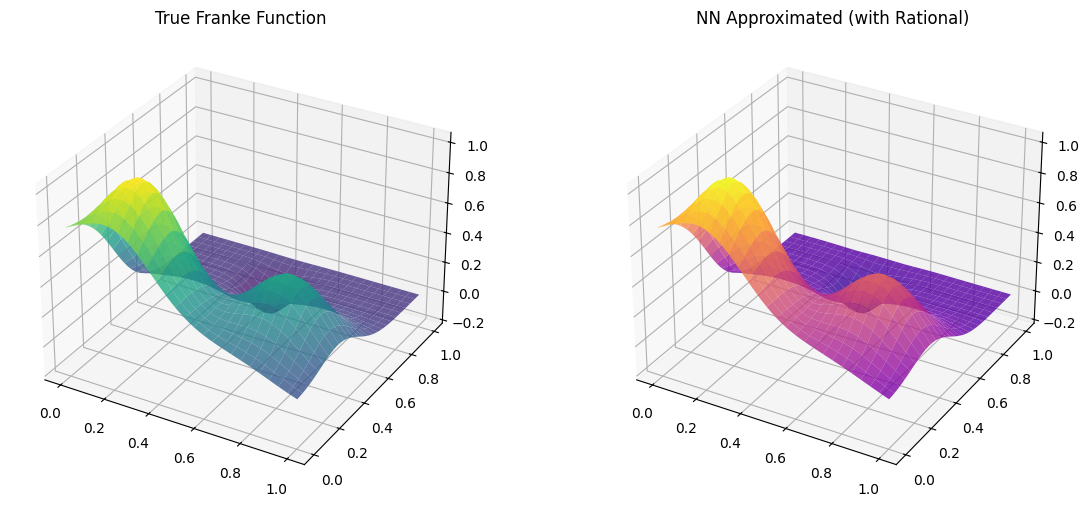

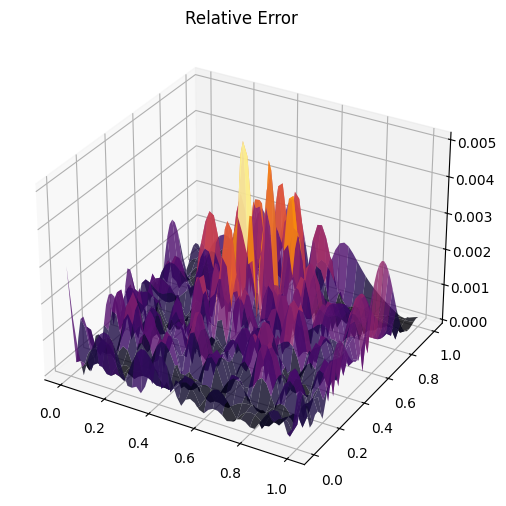

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Franke関数の定義
def franke_function(x, y):
    term1 = 0.75 * np.exp(-(9*x - 2)**2 / 4 - (9*y - 2)**2 / 4)
    term2 = 0.75 * np.exp(-(9*x + 1)**2 / 49 - (9*y + 1)**2 / 10)
    term3 = 0.50 * np.exp(-(9*x - 7)**2 / 4 - (9*y - 3)**2 / 4)
    term4 = -0.2 * np.exp(-(9*x - 4)**2 - (9*y - 7)**2)
    return term1 + term2 + term3 + term4

f = franke_function

# 2. データ生成
grid_size = 50
x_coord = np.linspace(0, 1, grid_size)
y_coord = np.linspace(0, 1, grid_size)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
features = torch.tensor(np.stack([X_mesh.ravel(), Y_mesh.ravel()], axis=1), dtype=torch.float32)
labels = torch.tensor(f(X_mesh.ravel(), Y_mesh.ravel()), dtype=torch.float32).view(-1, 1)

class RationalActivation(nn.Module):
    def __init__(self):
        super().__init__()
        # Padé近似形式の係数を学習可能パラメータとして定義
        # 初期値は ReLU に近い挙動をするよう調整
        self.a = nn.Parameter(torch.tensor([0.0, 1.0, 0.0])) # 分子: a0 + a1*x + a2*x^2
        self.b = nn.Parameter(torch.tensor([0.0, 0.0, 0.1])) # 分母: 1 + b1*x + b2*x^2
        
    def forward(self, x):
        numerator = self.a[0] + self.a[1] * x + self.a[2] * x**2
        denominator = 1.0 + self.b[1] * x + self.b[2] * x**2
        return numerator / (denominator + 1e-6) # ゼロ除算防止

# 3. モデル定義 (Rational Activation を使用)
class Rational_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),  # 幅を64に縮小
            RationalActivation(),         # 活性化関数
            nn.Linear(64, 64), # 中間層1
            RationalActivation(),
            nn.Linear(64, 64), # 中間層2
            RationalActivation(),
            nn.Linear(64, 64), # 中間層3
            RationalActivation(),
            nn.Linear(64, 1)   # 出力層
        )
    def forward(self, x):
        return self.net(x)


model = Rational_MLP()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# 【重要】学習スケジューラの定義
# factor: 学習率を何倍にするか, patience: 何エポック改善しなかったら下げるか
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=100
)

criterion = nn.MSELoss()

# 訓練ループ
print("学習を開始します...")
for epoch in range(5000):
    optimizer.zero_grad()
    pred = model(features)
    loss = criterion(pred, labels)
    loss.backward()
    optimizer.step()
    
    # スケジューラに損失を報告して学習率を更新
    scheduler.step(loss)
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}: Loss {loss.item():.6e} | LR {optimizer.param_groups[0]['lr']:.6f}")

print("訓練が完了しました。")


# 4. 近似用ラッパー関数
def f_approx(x, y):
    coords = torch.tensor(np.stack([np.array(x).ravel(), np.array(y).ravel()], axis=1), dtype=torch.float32)
    with torch.no_grad():
        res = model(coords).numpy().reshape(np.shape(x))
    return res

# 5. 誤差解析
n_eval = 51
x_eval = np.linspace(0, 1, n_eval)
y_eval = np.linspace(0, 1, n_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval, indexing='ij')
f_eval = f(X_eval, Y_eval)
f_eval_approx = f_approx(X_eval, Y_eval)

abs_err = np.abs(f_eval - f_eval_approx)
rel_err = abs_err / np.max(np.abs(f_eval))
print(f"Max Relative Error: {np.max(rel_err):.6f}")

# 6. 可視化
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_eval, Y_eval, f_eval, cmap='viridis', alpha=0.8)
ax1.set_title("True Franke Function")

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_eval, Y_eval, f_eval_approx, cmap='plasma', alpha=0.8)
ax2.set_title("NN Approximated (with Rational)")

fig_err = plt.figure(figsize=(7, 6))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
ax3.plot_surface(X_eval, Y_eval, rel_err, cmap='inferno', alpha=0.8)
ax3.set_title("Relative Error")

plt.show()